In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns

**Загрузка датасета**


In [ ]:
data = fetch_ucirepo(id=144)

X = data.data.features.copy()
y = data.data.targets.copy()

columns = [
    "checking_account",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings",
    "employment",
    "installment_rate",
    "personal_status",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "dependents",
    "telephone",
    "foreign_worker"
]

X.columns = columns

df = X.copy()

df["target"] = y["class"]

# 1 = дефолт
# 0 = не дефолт
df["default"] = (df["target"] == 2).astype(int)

print("Размер:", df.shape)
print()

display(df.head())

Размер: (1000, 22)



,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,...,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,target,default
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,67,A143,A152,2,A173,1,A192,A201,1,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,22,A143,A152,1,A173,1,A191,A201,2,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,49,A143,A152,1,A172,2,A191,A201,1,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,45,A143,A153,1,A173,2,A191,A201,1,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,53,A143,A153,2,A173,2,A191,A201,2,1


**Расшифровка категориальных кодов**

In [ ]:
df["checking_account"] = df["checking_account"].map({
    "A11": "< 0 DM",
    "A12": "0-200 DM",
    "A13": ">= 200 DM",
    "A14": "no account"
})

df["credit_history"] = df["credit_history"].map({
    "A30": "no credits / all paid",
    "A31": "all credits paid",
    "A32": "existing credits paid duly",
    "A33": "delay in paying",
    "A34": "critical / other credits"
})

df["purpose"] = df["purpose"].map({
    "A40": "new car",
    "A41": "used car",
    "A42": "furniture / equipment",
    "A43": "radio / television",
    "A44": "domestic appliances",
    "A45": "repairs",
    "A46": "education",
    "A47": "vacation",
    "A48": "retraining",
    "A49": "business",
    "A410": "other"
})

df["savings"] = df["savings"].map({
    "A61": "< 100 DM",
    "A62": "100-500 DM",
    "A63": "500-1000 DM",
    "A64": ">= 1000 DM",
    "A65": "unknown / no savings"
})

df["employment"] = df["employment"].map({
    "A71": "unemployed",
    "A72": "< 1 year",
    "A73": "1-4 years",
    "A74": "4-7 years",
    "A75": ">= 7 years"
})

df["personal_status"] = df["personal_status"].map({
    "A91": "male: divorced / separated",
    "A92": "female: divorced / separated / married",
    "A93": "male: single",
    "A94": "male: married / widowed",
    "A95": "female: single"
})

df["other_debtors"] = df["other_debtors"].map({
    "A101": "none",
    "A102": "co-applicant",
    "A103": "guarantor"
})

df["property"] = df["property"].map({
    "A121": "real estate",
    "A122": "building society / life insurance",
    "A123": "car / other",
    "A124": "unknown / no property"
})

df["other_installment_plans"] = df["other_installment_plans"].map({
    "A141": "bank",
    "A142": "stores",
    "A143": "none"
})

df["housing"] = df["housing"].map({
    "A151": "rent",
    "A152": "own",
    "A153": "for free"
})

df["job"] = df["job"].map({
    "A171": "unemployed / unskilled non-resident",
    "A172": "unskilled resident",
    "A173": "skilled / official",
    "A174": "management / self-employed / highly qualified"
})

df["telephone"] = df["telephone"].map({
    "A191": "none",
    "A192": "yes, registered"
})

df["foreign_worker"] = df["foreign_worker"].map({
    "A201": "yes",
    "A202": "no"
})

**Проверка категориальных признаков**


In [ ]:
categorical_cols = [
    "checking_account",
    "credit_history",
    "purpose",
    "savings",
    "employment",
    "personal_status",
    "other_debtors",
    "property",
    "other_installment_plans",
    "housing",
    "job",
    "telephone",
    "foreign_worker"
]

for col in categorical_cols:
    print("=" * 60)
    print(col)
    print(df[col].value_counts(dropna=False))

checking_account
checking_account
no account    394
< 0 DM        274
0-200 DM      269
>= 200 DM      63
Name: count, dtype: int64
credit_history
credit_history
existing credits paid duly    530
critical / other credits      293
delay in paying                88
all credits paid               49
no credits / all paid          40
Name: count, dtype: int64
purpose
purpose
radio / television       280
new car                  234
furniture / equipment    181
used car                 103
business                  97
education                 50
repairs                   22
domestic appliances       12
other                     12
retraining                 9
Name: count, dtype: int64
savings
savings
< 100 DM                603
unknown / no savings    183
100-500 DM              103
500-1000 DM              63
>= 1000 DM               48
Name: count, dtype: int64
employment
employment
1-4 years     339
>= 7 years    253
4-7 years     174
< 1 year      172
unemployed     62
Name: count, dty

In [ ]:
pd.set_option("display.max_columns", None)

display(df.head())

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,residence_since,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,target,default
0,< 0 DM,6,critical / other credits,radio / television,1169,unknown / no savings,>= 7 years,4,male: single,none,4,real estate,67,none,own,2,skilled / official,1,"yes, registered",yes,1,0
1,0-200 DM,48,existing credits paid duly,radio / television,5951,< 100 DM,1-4 years,2,female: divorced / separated / married,none,2,real estate,22,none,own,1,skilled / official,1,none,yes,2,1
2,no account,12,critical / other credits,education,2096,< 100 DM,4-7 years,2,male: single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,1,0
3,< 0 DM,42,existing credits paid duly,furniture / equipment,7882,< 100 DM,4-7 years,2,male: single,guarantor,4,building society / life insurance,45,none,for free,1,skilled / official,2,none,yes,1,0
4,< 0 DM,24,delay in paying,new car,4870,< 100 DM,1-4 years,3,male: single,none,4,unknown / no property,53,none,for free,2,skilled / official,2,none,yes,2,1


**Разделение переменных на категориальные и числовые для WOE/IV**

In [ ]:
numeric_cols = [
    "duration",
    "credit_amount",
    "installment_rate",
    "residence_since",
    "age",
    "existing_credits",
    "dependents"
]

categorical_cols = [
    "checking_account",
    "credit_history",
    "purpose",
    "savings",
    "employment",
    "personal_status",
    "other_debtors",
    "property",
    "other_installment_plans",
    "housing",
    "job",
    "telephone",
    "foreign_worker"
]

In [ ]:
print("Числовые:")
print(numeric_cols)

print("\nКатегориальные:")
print(categorical_cols)

Числовые:
['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'dependents']

Категориальные:
['checking_account', 'credit_history', 'purpose', 'savings', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


**Смотрим долю дефолтов в датасете**

In [ ]:
print(df["default"].value_counts())

print("\nДоли:")
print(df["default"].value_counts(normalize=True))

default
0    700
1    300
Name: count, dtype: int64

Доли:
default
0    0.7
1    0.3
Name: proportion, dtype: float64


**Смотрим диапазоны переменных**

In [ ]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


Смотрим форму распределения числовых признаков у дефолтных и недефолтных заёмщиков. Если распределения сильно различаются, то можно сказать, что признак несёт предиктивную силу.

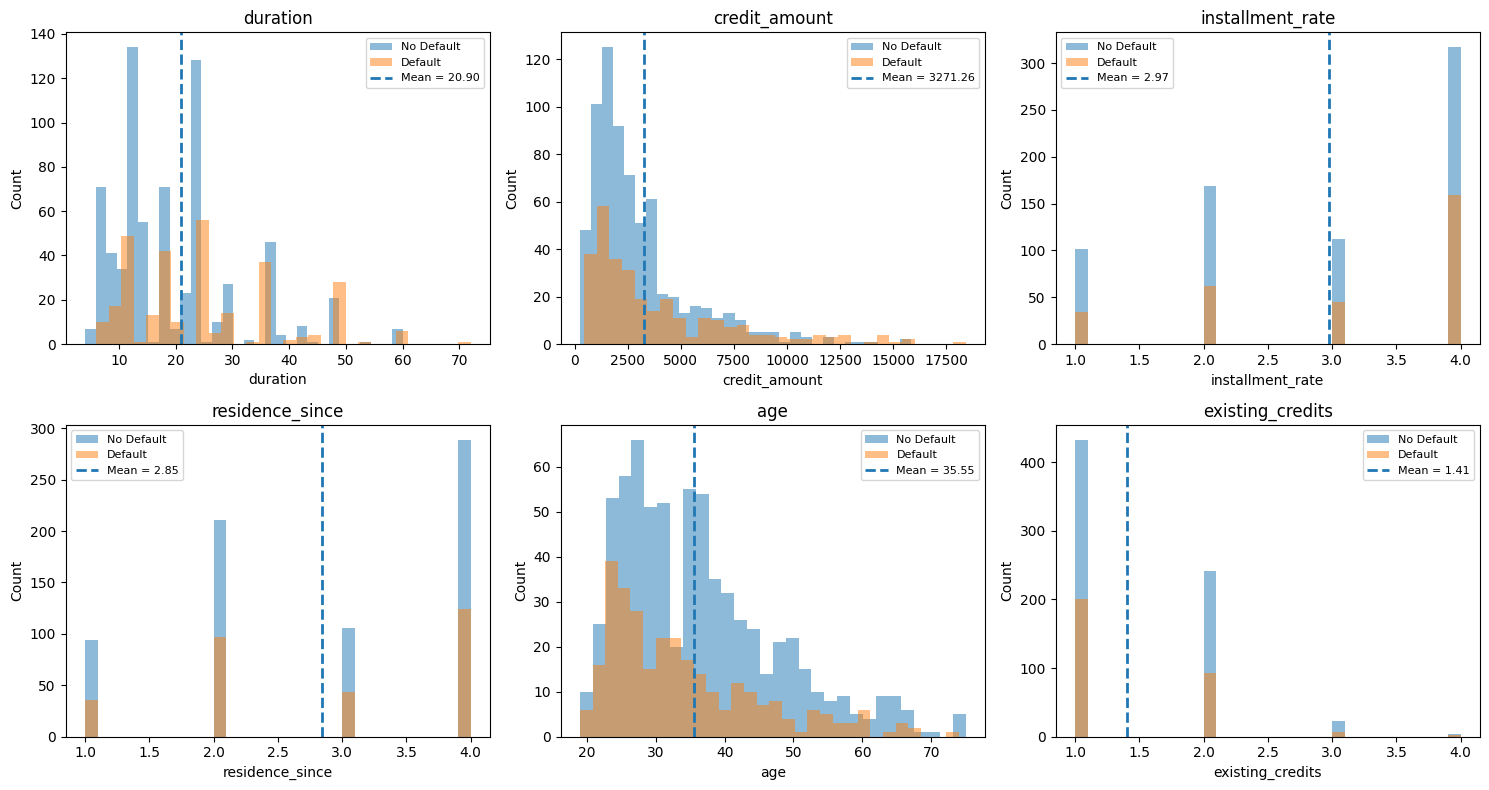

In [ ]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8)
)

axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):

  x0 = df.loc[df["default"] == 0, col].dropna()
  x1 = df.loc[df["default"] == 1, col].dropna()

  mean = df[col].mean()

  ax.hist(x0, bins = 30, alpha = 0.5, label = "No Default")
  ax.hist(x1, bins = 30, alpha = 0.5, label = "Default")

  ax.axvline(
        mean,
        linestyle='--',
        linewidth=2,
        label=f'Mean = {mean:.2f}'
  )

  ax.set_title(col)
  ax.set_xlabel(col)
  ax.set_ylabel('Count')
  ax.legend(fontsize=8)

for ax in axes[len(numeric_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

**Проверка мультиколлинеарности между числовыми признаками, сильно скоррелированные пары нужно учесть при отборе признаков.**

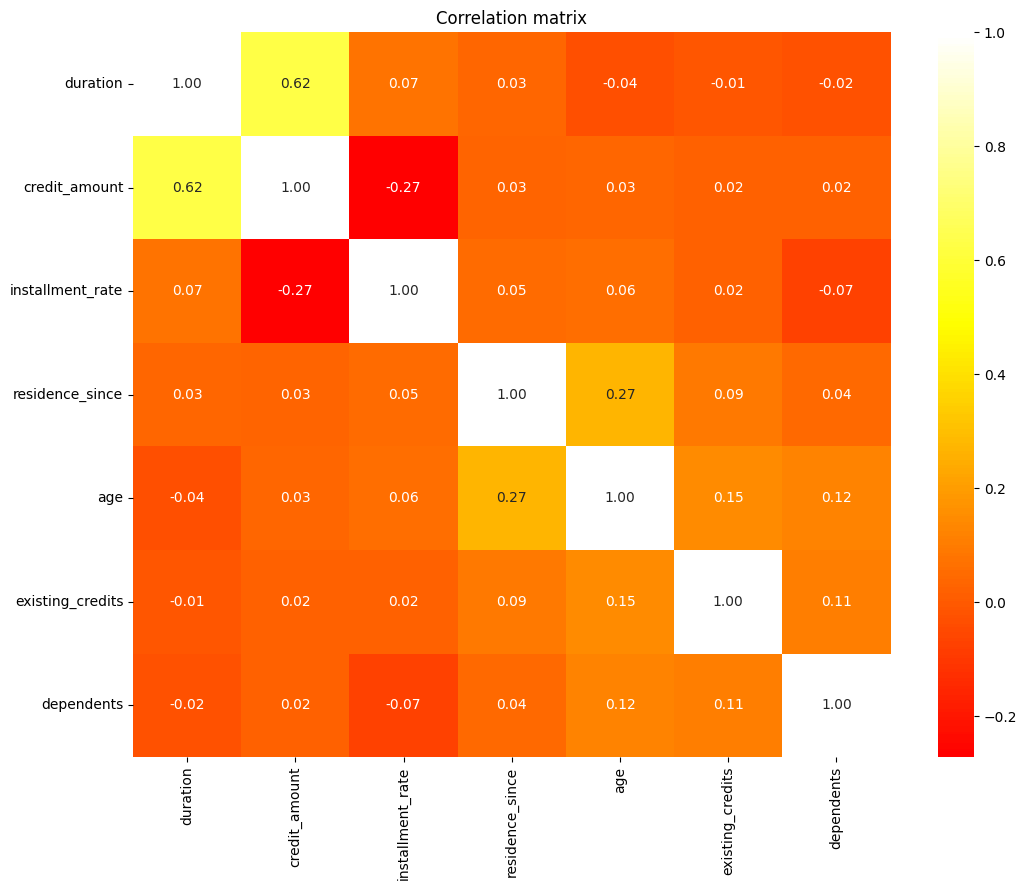

In [ ]:
plt.figure(figsize=(11, 9))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="hot", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

**Визуализация доли дефолтов внутри каждой категории**

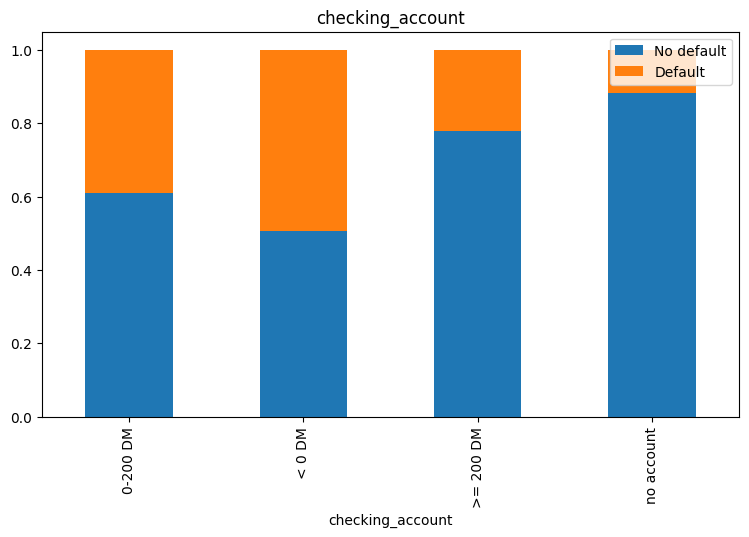

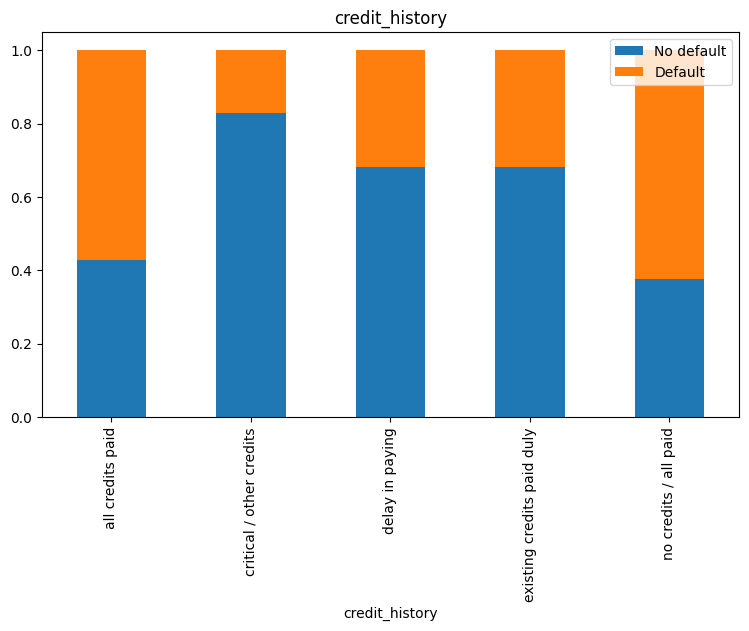

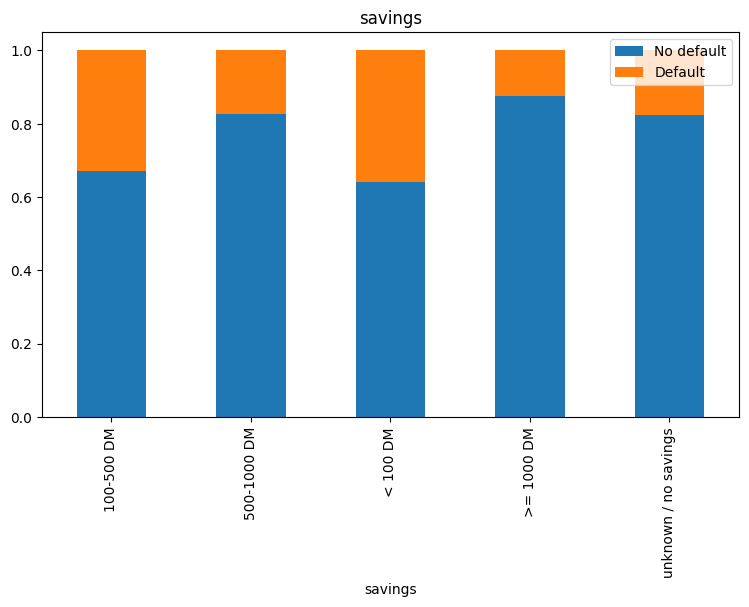

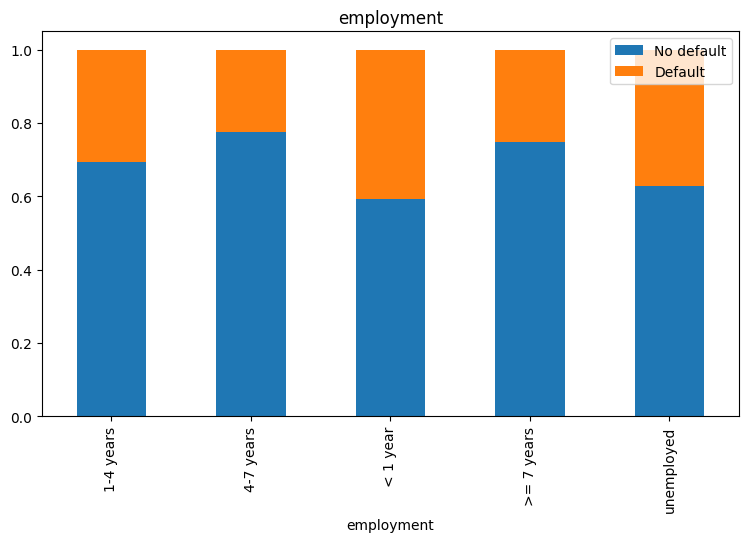

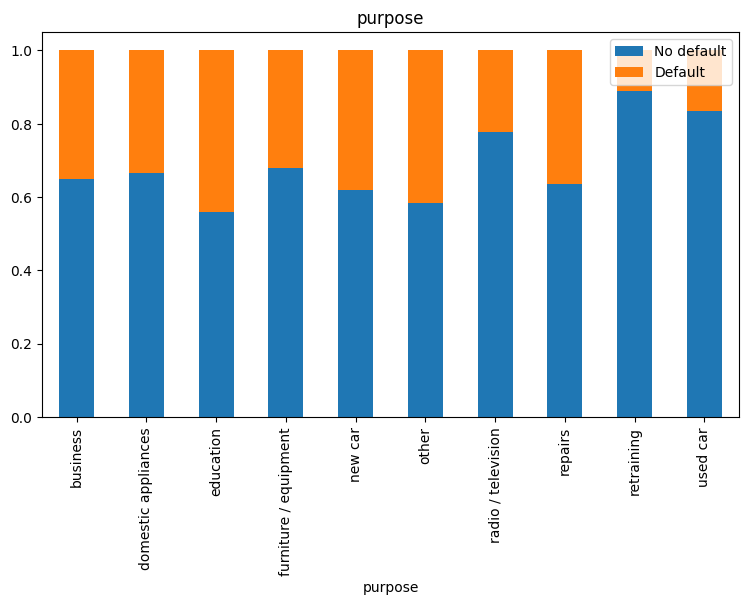

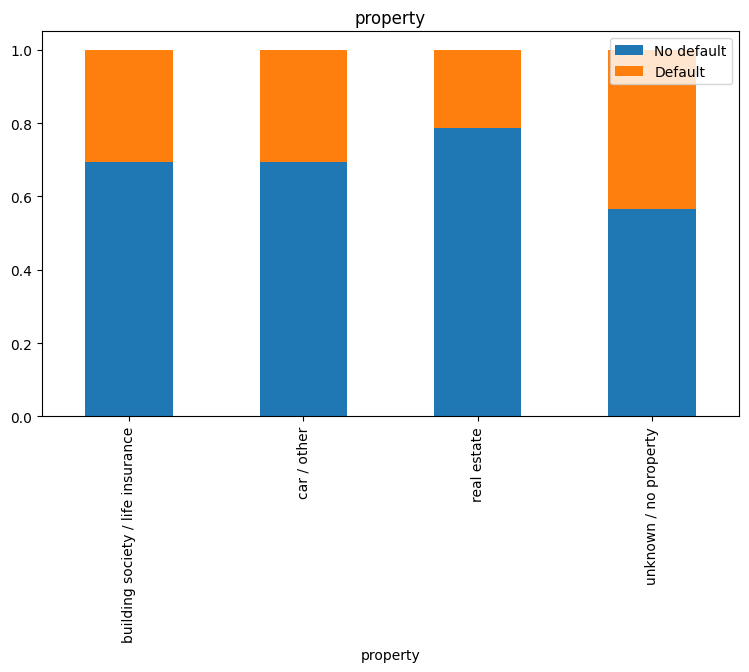

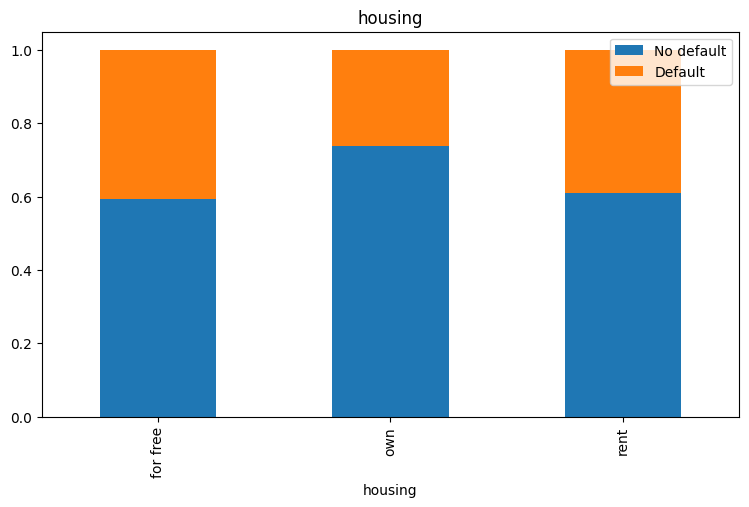

In [ ]:
cols = ["checking_account",
    "credit_history",
    "savings",
    "employment",
    "purpose",
    "property",
    "housing"]

for col in cols:
  counts = pd.crosstab(
      df[col],
      df["default"],
      normalize="index"
  )

  counts.columns = ["No default", "Default"]

  counts.plot(
      kind="bar",
      stacked=True,
      title = col,
      figsize=(9, 5)
  )

plt.show()

**Разбиение выборки на тренировочную и тестовую с сохранением пропорций классов.**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["target", "default"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

train = X_train.copy()
train["default"] = y_train

test = X_test.copy()
test["default"] = y_test

print("Train:", train.shape)
print("Test:", test.shape)

Train: (700, 21)
Test: (300, 21)


- `WOE = ln(good/bad)` чем больше WOE тем безопаснее бин относительно остальных
- `IV = Σ(good − bad)*WOE` суммарная предиктивная сила признака

Здесь `bad = default = 1`, `good = default = 0`.

In [ ]:
def calculate_woe_iv(df, col, target):
  table = (df.groupby(col)[target].agg(total = "count", bad = "sum"))
  table["good"] = table["total"] - table["bad"]

  good = table["good"].sum()
  bad = table["bad"].sum()

  table["bad_rate"] = table["bad"] / bad
  table["good_rate"] = table["good"] / good

  table["woe"] = np.log(table["good_rate"] / table["bad_rate"])

  table["iv"] = ((table["good_rate"] - table["bad_rate"])* table["woe"])

  iv = table["iv"].sum()

  return table, iv

**Смотрим WOE по checking_account**

In [ ]:
woe_table, iv = calculate_woe_iv(
    train,
    "checking_account",
    "default"
)

display(woe_table)

print("IV =", iv)

,total,bad,good,bad_rate,good_rate,woe,iv
checking_account,,,,,,,
0-200 DM,188,74,114,0.352381,0.232653,-0.415165,0.049707
< 0 DM,192,92,100,0.438095,0.204082,-0.763916,0.178767
>= 200 DM,44,12,32,0.057143,0.065306,0.133531,0.001090
no account,276,32,244,0.152381,0.497959,1.184134,0.409211


IV = 0.6387747121593845


**Смотрим IV по всем категориальным признакам**

In [ ]:
categorical_iv = []

for col in categorical_cols:

    table, iv = calculate_woe_iv(
        train,
        col,
        "default"
    )

    categorical_iv.append({
        "feature": col,
        "IV": iv
    })

iv_df = pd.DataFrame(categorical_iv)

iv_df = iv_df.sort_values(
    "IV",
    ascending=False
)

display(iv_df)

,feature,IV
0,checking_account,0.638775
1,credit_history,0.254391
3,savings,0.233467
4,employment,0.140286
7,property,0.140196
2,purpose,0.132244
8,other_installment_plans,0.116911
9,housing,0.102040
12,foreign_worker,0.076739
5,personal_status,0.039194


Получаем, что checling_account, слишком сильный признак IV > 0.5, что подозрительно, но так как признак фактически напрямую показывает платежеспособность клиента на момент подачи заявки, такой IV выглядит довольно обосновано.

**Визуализация полученных IV.**

<Figure size 1000x600 with 0 Axes>

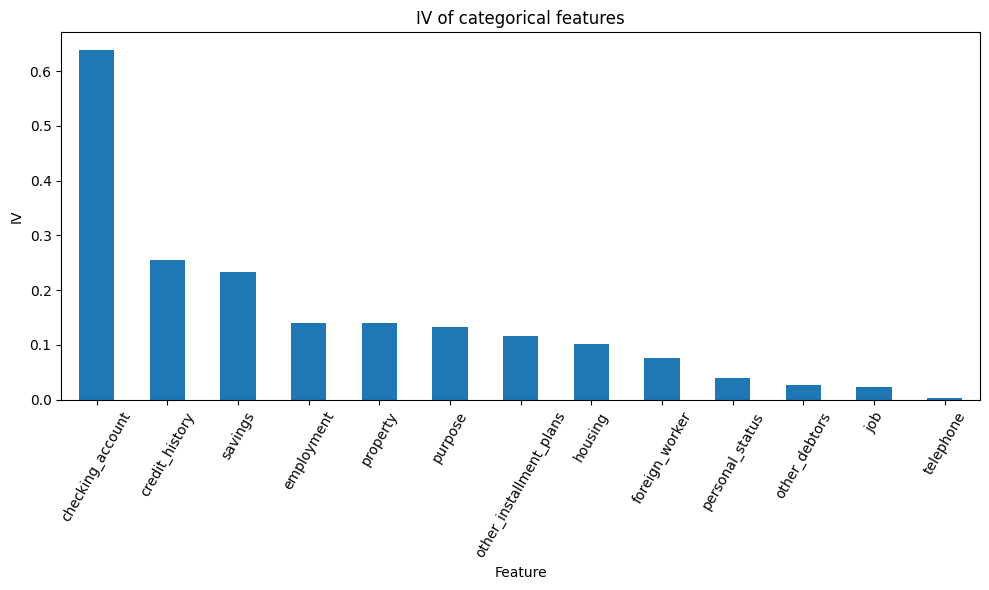

In [ ]:
plt.figure(figsize=(10, 6))

iv_df.plot(
    x="feature",
    y="IV",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.ylabel("IV")
plt.xlabel("Feature")
plt.title("IV of categorical features")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

Для числовых признаков сначала нужно разбить их на квантильные интервалы, и только потом внутри каждого интервала считать WOE так же, как для категорий.

In [ ]:
def add_quantile_bins(df, col, n_bins=5):

    result = df.copy()

    result[col + "_bin"] = pd.qcut(
        result[col],
        q=n_bins,
        duplicates="drop"
    )

    return result

In [ ]:
numeric_iv = []

for col in numeric_cols:

    temp = add_quantile_bins(
        train,
        col,
        n_bins=5
    )

    bin_col = col + "_bin"

    table, iv = calculate_woe_iv(
        temp,
        bin_col,
        "default"
    )

    numeric_iv.append({
        "feature": col,
        "IV": iv
    })

numeric_iv_df = pd.DataFrame(
    numeric_iv
).sort_values(
    "IV",
    ascending=False
)

display(numeric_iv_df)

/tmp/ipykernel_696/2033551689.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = (df.groupby(col)[target].agg(total = "count", bad = "sum"))
/tmp/ipykernel_696/2033551689.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = (df.groupby(col)[target].agg(total = "count", bad = "sum"))
/tmp/ipykernel_696/2033551689.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = (df.groupby(col)[target].agg(total

,feature,IV
0,duration,0.187094
1,credit_amount,0.064870
4,age,0.047752
2,installment_rate,0.033222
3,residence_since,0.001131
5,existing_credits,0.000646
6,dependents,0.000000


**Итоговая IV таблица по всем признакам.**

In [ ]:
all_iv = pd.concat(
    [
        iv_df,
        numeric_iv_df
    ],
    ignore_index=True
)

all_iv = all_iv.sort_values(
    "IV",
    ascending=False
)

display(all_iv)

,feature,IV
0,checking_account,0.638775
1,credit_history,0.254391
2,savings,0.233467
13,duration,0.187094
3,employment,0.140286
4,property,0.140196
5,purpose,0.132244
6,other_installment_plans,0.116911
7,housing,0.102040
8,foreign_worker,0.076739


<Figure size 1000x600 with 0 Axes>

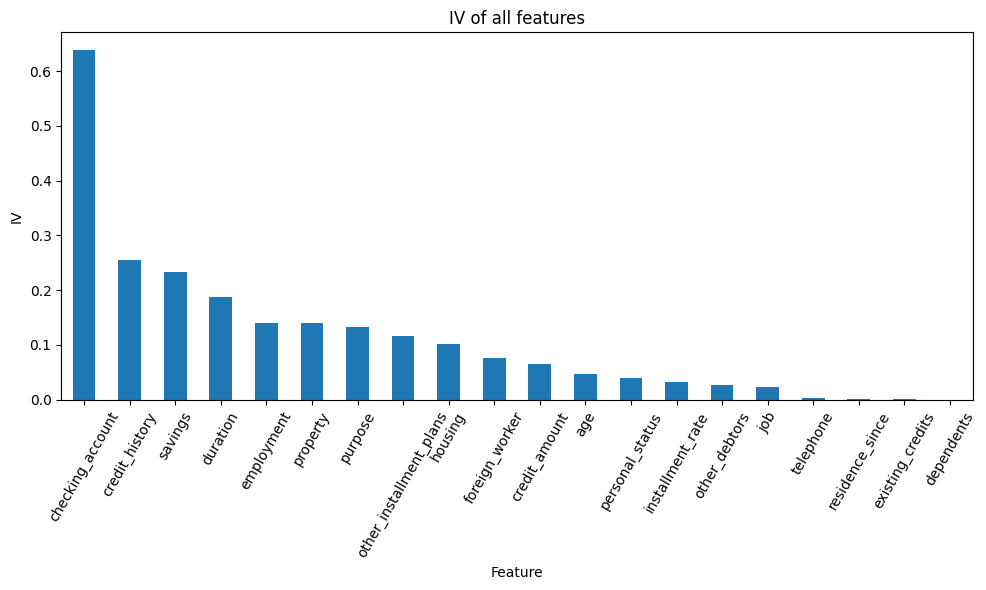

In [ ]:
plt.figure(figsize=(10, 6))

all_iv.plot(
    x="feature",
    y="IV",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.ylabel("IV")
plt.xlabel("Feature")
plt.title("IV of all features")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

Таким образом, видим что наибольший вес имеют: текущее кол-во денег на счету, уже закрытые кредиты и сбережения на момент подачи заявки.

Берем признаки для которых IV > 0.02

In [ ]:
IV_THRESHOLD = 0.02

selected_features = all_iv.loc[all_iv["IV"] >= IV_THRESHOLD, "feature"].tolist()

print(f"Отобрано признаков: {len(selected_features)} из {len(all_iv)}")
print(selected_features)


Отобрано признаков: 16 из 20
['checking_account', 'credit_history', 'savings', 'duration', 'employment', 'property', 'purpose', 'other_installment_plans', 'housing', 'foreign_worker', 'credit_amount', 'age', 'personal_status', 'installment_rate', 'other_debtors', 'job']


Переводим каждый отобранный признак в WOE, посчитанный на тренировочной выборке, и применяем эти же бины/веса к test.

In [ ]:
def fit_woe(train_df, col, target, is_numeric=False, n_bins=5):
    if is_numeric:
        binned, bin_edges = pd.qcut(train_df[col], q=n_bins, duplicates="drop", retbins=True)
        tmp = train_df.copy()
        tmp[col + "_bin"] = binned.astype(str)
        table, iv = calculate_woe_iv(tmp, col + "_bin", target)
        return table, iv, bin_edges
    else:
        tmp = train_df.copy()
        tmp[col] = tmp[col].astype(str)
        table, iv = calculate_woe_iv(tmp, col, target)
        return table, iv, None


def apply_woe(df_input, col, woe_table, is_numeric=False, bin_edges=None):
    woe_map = woe_table["woe"].to_dict()
    fallback = woe_table["woe"].mean()  # на случай нового бина

    if is_numeric:
        binned = pd.cut(df_input[col], bins=bin_edges, include_lowest=True).astype(str)
        return binned.map(woe_map).fillna(fallback)
    else:
        return df_input[col].astype(str).map(woe_map).fillna(fallback)


In [ ]:
woe_tables = {}
bin_edges_map = {}

woe_train = pd.DataFrame(index=train.index)
woe_test = pd.DataFrame(index=test.index)

for feat in selected_features:
    is_num = feat in numeric_cols

    table, iv, edges = fit_woe(train, feat, "default", is_numeric=is_num, n_bins=5)
    woe_tables[feat] = table
    bin_edges_map[feat] = edges

    woe_train[feat + "_woe"] = apply_woe(train, feat, table, is_numeric=is_num, bin_edges=edges).values
    woe_test[feat + "_woe"] = apply_woe(test, feat, table, is_numeric=is_num, bin_edges=edges).values

display(woe_train.head())


,checking_account_woe,credit_history_woe,savings_woe,duration_woe,employment_woe,property_woe,purpose_woe,other_installment_plans_woe,housing_woe,foreign_worker_woe,credit_amount_woe,age_woe,personal_status_woe,installment_rate_woe,other_debtors_woe,job_woe
10,-0.415165,-0.082842,-0.301787,0.491594,-0.579034,-0.034804,-0.180353,0.174622,-0.468861,-0.044951,0.338326,-0.350124,-0.246088,-0.100083,0.005997,0.039556
82,1.184134,-0.082842,-0.098061,-0.199466,0.074691,0.051449,-0.218689,0.174622,-0.468861,-0.044951,0.338326,-0.350124,-0.246088,-0.100083,0.005997,0.104261
827,1.184134,-1.134980,-0.301787,-0.199466,0.074691,-0.034804,-0.218689,-0.308301,0.214468,-0.044951,0.176513,0.141830,0.163420,0.241314,0.005997,0.039556
410,-0.415165,-0.082842,-0.301787,-0.199466,0.194156,-0.034804,0.384846,0.174622,0.214468,-0.044951,0.024098,-0.350124,-0.246088,-0.149489,0.005997,0.039556
48,1.184134,0.699082,-0.301787,0.491594,0.074691,0.051449,-0.180353,0.174622,0.214468,-0.044951,-0.411980,0.262743,0.163420,0.241314,0.005997,0.104261


**Строим logreg на WOE.**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

logreg = LogisticRegression(random_state=42)
logreg.fit(woe_train, y_train)

train_proba_lr = logreg.predict_proba(woe_train)[:, 1]
test_proba_lr = logreg.predict_proba(woe_test)[:, 1]

def gini(y_true, y_proba):
    return 2 * roc_auc_score(y_true, y_proba) - 1

print("Logistic Regression")
print(f"Train AUC: {roc_auc_score(y_train, train_proba_lr):.4f} | Gini: {gini(y_train, train_proba_lr):.4f}")
print(f"Test  AUC: {roc_auc_score(y_test, test_proba_lr):.4f} | Gini: {gini(y_test, test_proba_lr):.4f}")

coef_df = pd.DataFrame({
    "feature": woe_train.columns,
    "coefficient": logreg.coef_[0]
}).sort_values("coefficient")

display(coef_df)


Logistic Regression
Train AUC: 0.8235 | Gini: 0.6470
Test  AUC: 0.7999 | Gini: 0.5998


,feature,coefficient
13,installment_rate_woe,-1.328303
6,purpose_woe,-0.851058
2,savings_woe,-0.831988
12,personal_status_woe,-0.823534
3,duration_woe,-0.800680
0,checking_account_woe,-0.768793
9,foreign_worker_woe,-0.760438
7,other_installment_plans_woe,-0.753378
4,employment_woe,-0.672636
14,other_debtors_woe,-0.635614


**Теперь построим XGBoost для сравнения.**

In [ ]:
import xgboost as xgb

X_train_raw = X_train[selected_features].copy()
X_test_raw = X_test[selected_features].copy()

cat_selected = [c for c in selected_features if c in categorical_cols]
for col in cat_selected:
    X_train_raw[col] = X_train_raw[col].astype("category")
    X_test_raw[col] = X_test_raw[col].astype("category")

xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    random_state=42, enable_categorical=True, eval_metric="auc"
)
xgb_model.fit(X_train_raw, y_train)

train_proba_xgb = xgb_model.predict_proba(X_train_raw)[:, 1]
test_proba_xgb = xgb_model.predict_proba(X_test_raw)[:, 1]

print("XGBoost")
print(f"Train AUC: {roc_auc_score(y_train, train_proba_xgb):.4f} | Gini: {gini(y_train, train_proba_xgb):.4f}")
print(f"Test  AUC: {roc_auc_score(y_test, test_proba_xgb):.4f} | Gini: {gini(y_test, test_proba_xgb):.4f}")


XGBoost
Train AUC: 0.9534 | Gini: 0.9067
Test  AUC: 0.8011 | Gini: 0.6022


**Сравним обе модели**

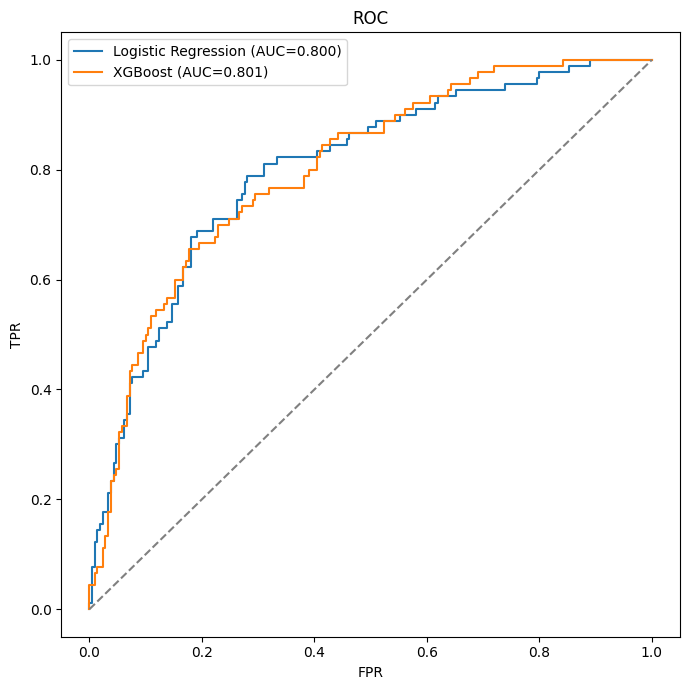

In [ ]:
plt.figure(figsize=(7, 7))

for name, y_proba in [("Logistic Regression", test_proba_lr), ("XGBoost", test_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC")
plt.legend()
plt.tight_layout()
plt.show()


**Выводы:**
- checking_account — доминирующий признак (IV=0.64), что в целом логично и обосновано.
- Логрегрессия на WOE даёт интерпретируемую модель, сопоставимую по качеству с XGBoost.
- На таком маленьком датасете можно говорить переобучении XGBoost и за сравнительно небольшой выборки. Это явно видно по падению Gini на тренировочной и тестовой выборках.